<a href="https://colab.research.google.com/github/Glaze0/Assignment/blob/main/16_Classification_Metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# R16 · Classification Metrics — Taj Hotels, Is 79 % Good?
**Last class** you built a decision tree that predicts cancellations with 79 % accuracy.

**Today:** before Taj resells rooms based on it, find out what that 79 % hides, and choose the metric that matches what a mistake really costs.

## 0. Where R15 Left Off

In [1]:
!gdown 1BNSKS0Lg5S4-YWz3_TKXxq6ngC_p98U9

Downloading...
From: https://drive.google.com/uc?id=1BNSKS0Lg5S4-YWz3_TKXxq6ngC_p98U9
To: /content/hotel_bookings_5k.csv
100% 344k/344k [00:00<00:00, 92.2MB/s]


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score,
                             roc_auc_score, RocCurveDisplay)

In [3]:
bookings = pd.read_csv("hotel_bookings_5k.csv")
data = pd.get_dummies(bookings, drop_first=True, dtype=int)

data.head()

,lead_time,previous_cancellations,booking_changes,total_of_special_requests,required_car_parking_spaces,adr,adults,stays_in_week_nights,is_repeated_guest,is_canceled,...,deposit_type_Refundable,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,203,0,4,0,0,66.8,2,5,0,0,...,0,0,0,1,0,0,0,0,1,0
1,82,0,0,0,0,76.5,2,3,0,1,...,0,0,0,0,0,0,1,0,1,0
2,25,0,2,1,0,60.0,3,3,0,0,...,0,0,0,0,0,1,0,0,0,1
3,1,0,0,0,0,95.0,1,1,0,0,...,0,0,0,0,0,0,1,0,0,1
4,70,0,0,0,0,108.0,2,2,0,0,...,0,0,0,0,0,0,1,0,1,0


In [4]:
data.shape

(5000, 22)

In [5]:
X = data.drop(columns="is_canceled")
y = data["is_canceled"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [6]:
print(X_train.shape, X_test.shape)

(4000, 21) (1000, 21)


In [7]:
tree = DecisionTreeClassifier(max_depth=6, random_state=42)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)
score = round(accuracy_score(y_test, y_pred), 3)

print("tree accuracy:            ", score)
print("baseline (nobody cancels):", round(1 - y_test.mean(), 3))

tree accuracy:             0.79
baseline (nobody cancels): 0.619


## 1. The Confusion Matrix

In [8]:
from sklearn.metrics import (accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score,
                             roc_auc_score, RocCurveDisplay)

In [9]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[561,  58],
       [152, 229]])

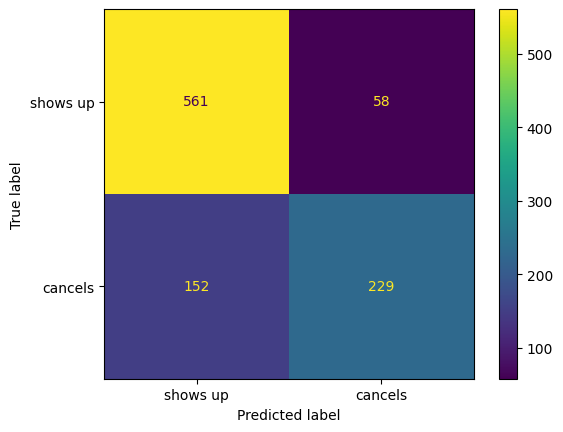

In [10]:
ConfusionMatrixDisplay(cm, display_labels=["shows up", "cancels"]).plot()
plt.show()

In [11]:
cm.ravel()

array([561,  58, 152, 229])

In [12]:
tn, fp, fn, tp = cm.ravel()
print("TN:", tn, "| FP:", fp, "| FN:", fn, "| TP:", tp)

print("accuracy by hand:", round((tn + tp) / (tn + fp + fn + tp), 3))

TN: 561 | FP: 58 | FN: 152 | TP: 229
accuracy by hand: 0.79


In [13]:
# Practice 1: the lazy model predicts "shows up" (0) for every booking.
# lazy_pred = [0] * len(y_test)
# Build its confusion matrix. What is its accuracy? How many cancellations does it catch?

## 2. Precision and Recall

In [14]:
(y_pred == 1).sum()

np.int64(287)

In [15]:
pr = 229/(229+58)
pr

0.7979094076655052

In [16]:
re = 229/381
re

0.6010498687664042

In [17]:
print("precision:", round(precision_score(y_test, y_pred), 3))  # of the bookings we flagged, how many cancelled?
print("recall:   ", round(recall_score(y_test, y_pred), 3)) # of the bookings that cancelled, how many did we flag?

precision: 0.798
recall:    0.601


In [18]:
f1 = 2 * pr * re / (pr + re)
f1

0.6856287425149701

In [19]:
# Practice 2: R15's unlimited depth tree -- DecisionTreeClassifier(random_state=42), no max_depth.
# Fit it, predict on X_test, and print its precision and recall. Compare with the depth-6 tree.

## 3. F1 score

In [20]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# print("simple average:", round((precision + recall) / 2, 3))
print("F1:            ", round(f1_score(y_test, y_pred), 3))

F1:             0.686


## 4. Moving the Threshold

In [21]:
# y_test

In [22]:
proba = tree.predict_proba(X_test)[:, 1]      # chance that each booking cancels
walk_cost = 12000     # guest arrives but the room was resold: upgrade, another hotel, taxi, apology
empty_cost = 4000     # booking cancelled and the room sat empty for a night

for threshold in [0.3, 0.5, 0.7, 0.9]:
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()


    print("threshold", threshold,
          "| precision", round(precision_score(y_test, pred), 3),
          "| recall", round(recall_score(y_test, pred), 3),
          "| fn", fn,
          "| fp", fp,
          "| tp", tp,
          "| cost Rs", fp * walk_cost + fn * empty_cost)

threshold 0.3 | precision 0.763 | recall 0.609 | fn 149 | fp 72 | tp 232 | cost Rs 1460000
threshold 0.5 | precision 0.798 | recall 0.601 | fn 152 | fp 58 | tp 229 | cost Rs 1304000
threshold 0.7 | precision 0.949 | recall 0.341 | fn 251 | fp 7 | tp 130 | cost Rs 1088000
threshold 0.9 | precision 0.969 | recall 0.333 | fn 254 | fp 4 | tp 127 | cost Rs 1064000


In [23]:
# ROC/AUC
# PR curve.

In [24]:
# Practice 3: New Year's week. An empty room now costs Rs 20,000 and walking a guest Rs 8,000.
# Change the two costs, add thresholds 0.1 and 0.2 to the list, and re-run. Which threshold wins now?

In [25]:
proba = tree.predict_proba(X_test)[:,1]
walking_cost = 8000
empty_cost = 20000

for threshold in [0.3,0.4,0.5,0.6,0.7,0.8,0.9]:
  pred = (proba >= threshold).astype(int)
  tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

  print(f'cost = {walking_cost * fp + empty_cost * fn}',
        f'TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}')


cost = 3556000 TP: 232, TN: 547, FP: 72, FN: 149
cost = 3524000 TP: 230, TN: 556, FP: 63, FN: 151
cost = 3504000 TP: 229, TN: 561, FP: 58, FN: 152
cost = 3504000 TP: 229, TN: 561, FP: 58, FN: 152
cost = 5076000 TP: 130, TN: 612, FP: 7, FN: 251
cost = 5076000 TP: 130, TN: 612, FP: 7, FN: 251
cost = 5112000 TP: 127, TN: 615, FP: 4, FN: 254


In [26]:
from sklearn.metrics import precision_recall_curve

In [27]:
y_proba = tree.predict_proba(X_test)[:, 1]
# y_proba

In [28]:
pr, re, thres = precision_recall_curve(y_test, y_proba)

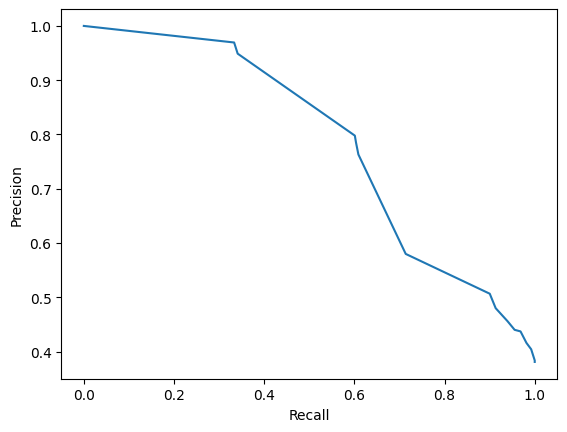

In [29]:
plt.plot(re, pr)
plt.xlabel("Recall")
plt.ylabel("Precision");

In [30]:
# thres

## 5. ROC Curve and AUC

In [31]:
logistic = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
logistic.fit(X_train, y_train)

print("accuracy  tree:", round(accuracy_score(y_test, tree.predict(X_test)), 3),
      "| logistic:", round(accuracy_score(y_test, logistic.predict(X_test)), 3))
print("AUC       tree:", round(roc_auc_score(y_test, tree.predict_proba(X_test)[:, 1]), 3),
      "| logistic:", round(roc_auc_score(y_test, logistic.predict_proba(X_test)[:, 1]), 3))

accuracy  tree: 0.79 | logistic: 0.783
AUC       tree: 0.809 | logistic: 0.838


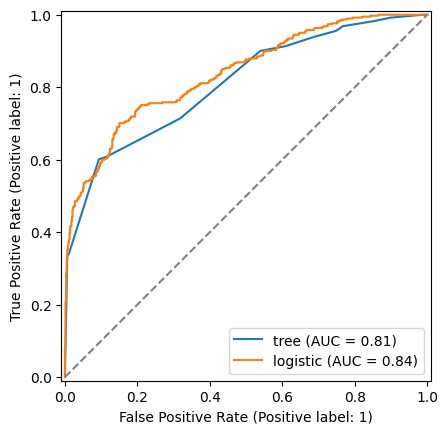

In [32]:
ax = plt.gca()
RocCurveDisplay.from_estimator(tree, X_test, y_test, name="tree", ax=ax)
RocCurveDisplay.from_estimator(logistic, X_test, y_test, name="logistic", ax=ax)
plt.plot([0, 1], [0, 1], "--", color="grey")     # random guessing
plt.show()

In [32]:
from sklearn.model_selection import De

## Interview prep
1. Why is accuracy misleading on imbalanced data?
2. Define precision and recall.
3. Give an example where precision matters more, and one where recall matters more.
4. Why does F1 use the harmonic mean?
5. What happens when you lower the threshold?
6. How do you choose a threshold?
7. What do the axes of an ROC curve show?
8. What does AUC mean?
9. Model A has higher accuracy, model B has higher AUC. Which do you choose?
10. Can AUC be misleading?
11. What is a Type I and a Type II error?
12. What is specificity?